 Initializing EDA & Feature Engineering Pipeline...

 Raw Dataset Shape: 100000 rows, 19 columns

🔍 Checking for Missing Values:
PRIS_No                 0
Supplier_Name           0
Part_Code               0
Part_Description        0
Total_Received_Qty      0
Rejected_Qty            0
Scrap_Qty               0
Unit_Cost_INR           0
Inventory_Location      0
Rejected_Category       0
Inventory_Category      0
Shift_Timing            0
Inspector_ID            0
Defect_Severity         0
Transit_Time_Days       0
Rejection_Date          0
Total_Scrap_Cost_INR    0
Rejection_Rate_Pct      0
Risk_Label              0
dtype: int64

 Engineering New Machine Learning Features...

 Generating EDA Visualizations...


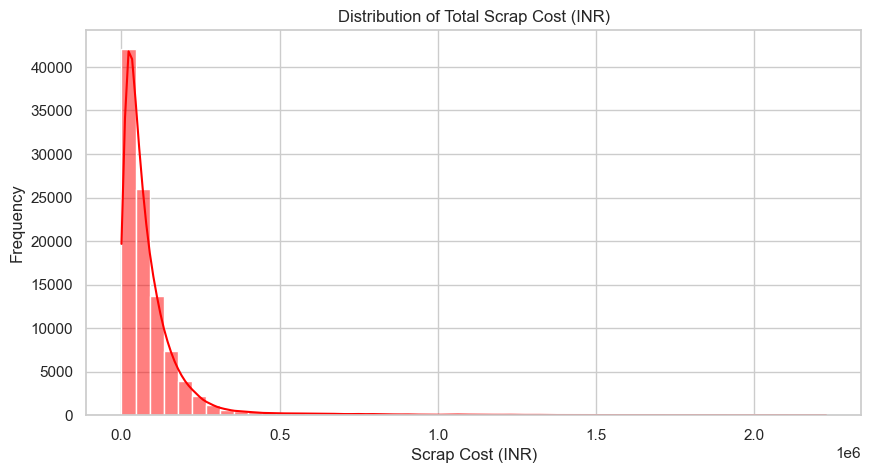

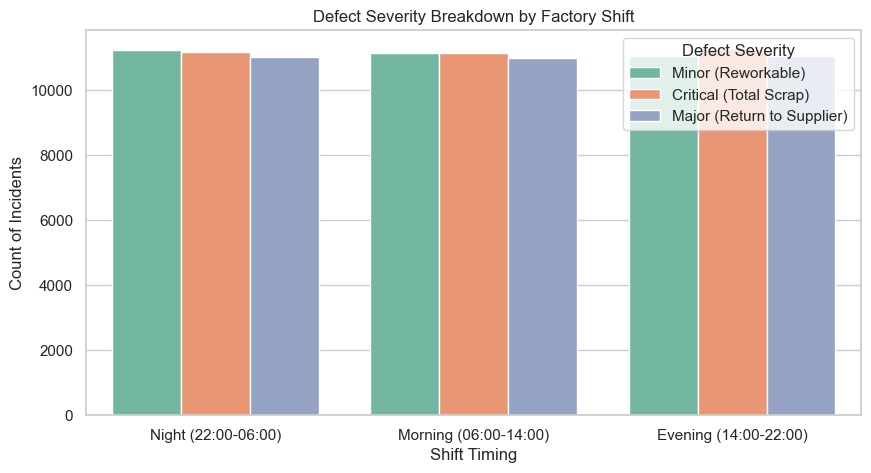


 Feature Engineering Complete. Clean dataset saved to: ../data/processed/honda_wms_engineered.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style for our EDA charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(" Initializing EDA & Feature Engineering Pipeline...")


# 1. DATA INGESTION & QUALITY CHECK (Points 1 & 2)

# Load data from our secure raw folder

file_path = "../data/Honda_Mega_PRIS_Dataset_100k.csv"
df = pd.read_csv(file_path)

print(f"\n Raw Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n🔍 Checking for Missing Values:")
print(df.isnull().sum())


# 2. FEATURE ENGINEERING (Point 4)

print("\n Engineering New Machine Learning Features...")

# Feature A: Transit Anomaly Flag
# If transit time is more than 20% higher than the average, flag it.
avg_transit = df['Transit_Time_Days'].mean()
df['Transit_Anomaly_Flag'] = np.where(df['Transit_Time_Days'] > (avg_transit * 1.2), 1, 0)

# Feature B: Financial Impact Score
# Recalculate strict scrap costs based on unit cost
df['Total_Scrap_Cost_INR'] = df['Scrap_Qty'] * df['Unit_Cost_INR']

# Feature C: Rejection Rate Percentage
# Prevent division by zero errors safely
df['Rejection_Rate_Pct'] = np.where(
    df['Total_Received_Qty'] > 0, 
    round((df['Rejected_Qty'] / df['Total_Received_Qty']) * 100, 2), 
    0
)

# 3. EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATIONS

print("\n Generating EDA Visualizations...")

# Plot 1: Distribution of Scrap Costs
plt.figure(figsize=(10, 5))
sns.histplot(df['Total_Scrap_Cost_INR'], bins=50, kde=True, color='red')
plt.title('Distribution of Total Scrap Cost (INR)')
plt.xlabel('Scrap Cost (INR)')
plt.ylabel('Frequency')
plt.show()

# Plot 2: Defect Severity by Shift Timing
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Shift_Timing', hue='Defect_Severity', palette='Set2')
plt.title('Defect Severity Breakdown by Factory Shift')
plt.xlabel('Shift Timing')
plt.ylabel('Count of Incidents')
plt.legend(title='Defect Severity')
plt.show()

# Save the newly engineered dataset to our 'processed' folder
processed_path = '../data/processed/honda_wms_engineered.csv'
df.to_csv(processed_path, index=False)
print(f"\n Feature Engineering Complete. Clean dataset saved to: {processed_path}")

In [2]:
import os

print(os.getcwd())

/Users/vihaans/Desktop/Honda_Disha_Analytics/notebooks


In [3]:
import os

print(os.getcwd())
print(os.listdir("../data"))

/Users/vihaans/Desktop/Honda_Disha_Analytics/notebooks
['.DS_Store', 'Honda_wms_raw.csv', 'processed']


In [4]:
from pathlib import Path

print("Current:", Path.cwd())

for p in Path("..").rglob("Honda_Mega_PRIS_Dataset_100k.csv"):
    print(p.resolve())

Current: /Users/vihaans/Desktop/Honda_Disha_Analytics/notebooks
/Users/vihaans/Desktop/Honda_Disha_Analytics/Honda_Mega_PRIS_Dataset_100k.csv
/Users/vihaans/Desktop/Honda_Disha_Analytics/data/Honda_wms_raw.csv/Honda_Mega_PRIS_Dataset_100k.csv


In [5]:
from pathlib import Path

print(Path("../data/Honda_Mega_PRIS_Dataset_100k.csv").exists())
print(Path("../data").resolve())
print(list(Path("../data").iterdir()))

False
/Users/vihaans/Desktop/Honda_Disha_Analytics/data
[PosixPath('../data/.DS_Store'), PosixPath('../data/Honda_wms_raw.csv'), PosixPath('../data/processed')]


In [7]:
from pathlib import Path

print(Path("../data/Honda_Mega_PRIS_Dataset_100k.csv").exists())

True
